In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

In [2]:
fund_master = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print("Fund Master:", fund_master.shape)
print("NAV:", nav.shape)
print("Transactions:", transactions.shape)
print("Portfolio:", portfolio.shape)

Fund Master: (40, 15)
NAV: (46000, 3)
Transactions: (32778, 13)
Portfolio: (322, 8)


In [3]:
# Daily Returns

nav['date'] = pd.to_datetime(nav['date'])
nav = nav.sort_values(['amfi_code', 'date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

# VaR and CVaR Calculation

var_cvar = []

for fund, group in nav.groupby('amfi_code'):
    
    returns = group['daily_return'].dropna()
    
    if len(returns) > 30:
        
        var_95 = np.percentile(returns, 5)
        cvar_95 = returns[returns <= var_95].mean()
        
        var_cvar.append([
            fund,
            var_95,
            cvar_95
        ])

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=['amfi_code', 'VaR_95', 'CVaR_95']
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [4]:
var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("var_cvar_report.csv saved")

var_cvar_report.csv saved


In [5]:
var_cvar_df.sort_values(
    'VaR_95'
).head(10)

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [6]:
# Rolling 90-Day Sharpe Ratio

rf_daily = 0.065 / 252

rolling_sharpe = {}

top_funds = nav['amfi_code'].unique()[:5]

for fund in top_funds:

    temp = nav[nav['amfi_code'] == fund].copy()

    returns = temp['daily_return']

    sharpe = (
        (returns.rolling(90).mean() - rf_daily)
        /
        returns.rolling(90).std()
    ) * np.sqrt(252)

    rolling_sharpe[fund] = sharpe

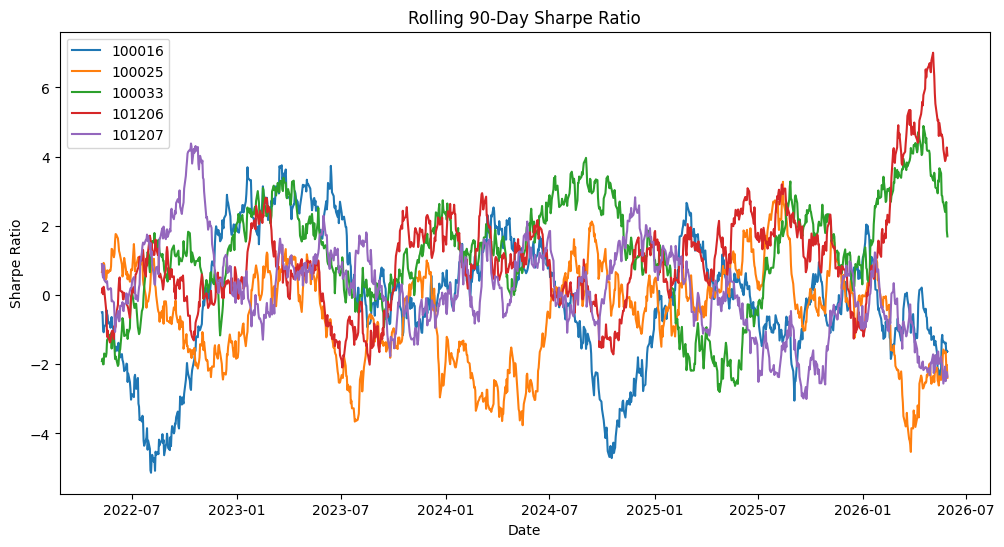

In [7]:
plt.figure(figsize=(12,6))

for fund in rolling_sharpe:
    plt.plot(
        nav[nav['amfi_code']==fund]['date'],
        rolling_sharpe[fund],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.show()

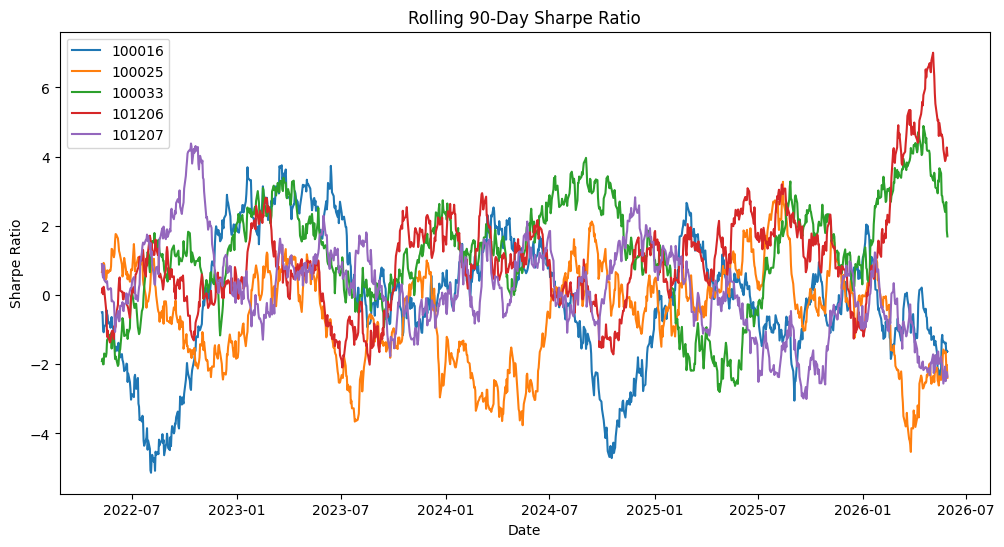

In [8]:
plt.figure(figsize=(12,6))

for fund in rolling_sharpe:
    plt.plot(
        nav[nav['amfi_code']==fund]['date'],
        rolling_sharpe[fund],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

In [9]:
# Investor Cohort Analysis

transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

# First transaction year per investor

first_txn = (
    transactions
    .groupby('investor_id')['transaction_date']
    .min()
    .reset_index()
)

first_txn['cohort_year'] = first_txn[
    'transaction_date'
].dt.year

transactions = transactions.merge(
    first_txn[['investor_id', 'cohort_year']],
    on='investor_id',
    how='left'
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [10]:
cohort_summary = (
    transactions
    .groupby('cohort_year')
    .agg(
        avg_investment=('amount_inr', 'mean'),
        total_invested=('amount_inr', 'sum')
    )
    .reset_index()
)

cohort_summary

,cohort_year,avg_investment,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [11]:
top_fund = (
    transactions
    .groupby(['cohort_year', 'amfi_code'])
    .size()
    .reset_index(name='count')
)

top_fund = (
    top_fund
    .sort_values(
        ['cohort_year', 'count'],
        ascending=[True, False]
    )
    .groupby('cohort_year')
    .head(1)
)

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [12]:
cohort_summary.merge(
    top_fund[['cohort_year', 'amfi_code']],
    on='cohort_year',
    how='left'
)

,cohort_year,avg_investment,total_invested,amfi_code
0,2024,107422.541832,3491125187,148568
1,2025,109158.577061,30455243,119599


In [13]:
# SIP Transactions Only

sip_txn = transactions[
    transactions['transaction_type']
    .str.upper()
    .str.contains('SIP', na=False)
].copy()

sip_txn = sip_txn.sort_values(
    ['investor_id', 'transaction_date']
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [14]:
# Gap between SIP dates

sip_txn['gap_days'] = (
    sip_txn
    .groupby('investor_id')['transaction_date']
    .diff()
    .dt.days
)

sip_txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0


In [15]:
# Investors with 6+ SIP transactions

sip_count = (
    sip_txn
    .groupby('investor_id')
    .size()
    .reset_index(name='sip_count')
)

eligible = sip_count[
    sip_count['sip_count'] >= 6
]

eligible.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [16]:
continuity = (
    sip_txn
    .merge(
        eligible[['investor_id']],
        on='investor_id',
        how='inner'
    )
    .groupby('investor_id')
    .agg(
        avg_gap_days=('gap_days', 'mean')
    )
    .reset_index()
)

continuity['status'] = np.where(
    continuity['avg_gap_days'] > 35,
    'At-Risk',
    'Active'
)

continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At-Risk
1,INV000008,70.400000,At-Risk
2,INV000010,64.800000,At-Risk
3,INV000011,40.166667,At-Risk
4,INV000012,57.000000,At-Risk


In [17]:
continuity['status'].value_counts()

status
At-Risk    1332
Active       30
Name: count, dtype: int64

In [18]:
# Check available risk grades

fund_master['risk_grade'].value_counts()

KeyError: 'risk_grade'

In [19]:
print(fund_master.columns)

Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')


In [20]:
recommender_df = fund_master.merge(
    sharpe_df[['amfi_code', 'Sharpe_Ratio']],
    on='amfi_code',
    how='left'
)

risk_input = "Moderate"

recommendations = (
    recommender_df[
        recommender_df['risk_category']
        .str.contains(risk_input, case=False, na=False)
    ]
    .sort_values(
        'Sharpe_Ratio',
        ascending=False
    )
    .head(3)
)

recommendations[
    [
        'scheme_name',
        'risk_category',
        'Sharpe_Ratio'
    ]
]

NameError: name 'sharpe_df' is not defined

In [21]:
sharpe_df = (
    nav.groupby('amfi_code')['daily_return']
    .agg(['mean', 'std'])
    .reset_index()
)

sharpe_df['Sharpe_Ratio'] = (
    (sharpe_df['mean'] - (0.065/252))
    / sharpe_df['std']
) * np.sqrt(252)

sharpe_df.head()

,amfi_code,mean,std,Sharpe_Ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [22]:
recommender_df = fund_master.merge(
    sharpe_df[['amfi_code', 'Sharpe_Ratio']],
    on='amfi_code',
    how='left'
)

risk_input = "Moderate"

recommendations = (
    recommender_df[
        recommender_df['risk_category']
        .str.contains(risk_input, case=False, na=False)
    ]
    .sort_values('Sharpe_Ratio', ascending=False)
    .head(3)
)

recommendations[
    ['scheme_name', 'risk_category', 'Sharpe_Ratio']
]

,scheme_name,risk_category,Sharpe_Ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.448291
22,Kotak Flexicap Fund - Regular - Growth,Moderately High,1.306744
0,SBI Bluechip Fund - Regular Plan - Growth,Moderate,1.208267


In [23]:
# HHI Concentration

portfolio['weight_pct'] = portfolio['weight_pct'] / 100

hhi_df = (
    portfolio.groupby('amfi_code')['weight_pct']
    .apply(lambda x: (x**2).sum())
    .reset_index(name='HHI')
)

hhi_df.sort_values(
    'HHI',
    ascending=False
).head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


In [24]:
hhi_df.describe()

,amfi_code,HHI
count,34.000000,34.000000
mean,121457.058824,0.140262
std,14988.778388,0.024946
min,100016.000000,0.107349
25%,118633.250000,0.122955
50%,119575.000000,0.136496
75%,120842.750000,0.151731
max,149324.000000,0.206448


In [25]:
# Advanced Insights

## 1. Risk Analysis
Funds with the highest VaR and CVaR exhibit significantly higher downside risk, indicating greater potential losses during adverse market conditions.

## 2. Rolling Performance
Rolling 90-day Sharpe Ratios show that risk-adjusted performance varies substantially over time, even among top-performing funds.

## 3. Investor Cohorts
Recent investor cohorts contributed the highest investment amounts, reflecting growing retail participation in mutual funds.

## 4. SIP Continuity
Most investors maintained regular SIP contributions, while at-risk investors with average gaps above 35 days may require engagement strategies.

## 5. Portfolio Concentration
Funds with high HHI values are concentrated in fewer holdings, increasing concentration risk compared to diversified funds.

SyntaxError: invalid syntax (306215969.py, line 4)

# Advanced Insights

## 1. Risk Analysis
Funds with the highest VaR and CVaR exhibit significantly higher downside risk, indicating greater potential losses during adverse market conditions.

## 2. Rolling Performance
Rolling 90-day Sharpe Ratios show that risk-adjusted performance varies substantially over time, even among top-performing funds.

## 3. Investor Cohorts
Recent investor cohorts contributed the highest investment amounts, reflecting growing retail participation in mutual funds.

## 4. SIP Continuity
Most investors maintained regular SIP contributions, while at-risk investors with average gaps above 35 days may require engagement strategies.

## 5. Portfolio Concentration
Funds with high HHI values are concentrated in fewer holdings, increasing concentration risk compared to diversified funds.